# 04 — ML energy resolution: a Crystal-Ball density network

[`03_resolution_conventional.ipynb`](03_resolution_conventional.ipynb) measured the energy
resolution the conventional way: dedicated fixed-energy runs, a Crystal-Ball fit at each
energy, and an inverted calibration. This notebook measures the **same quantity** with ML,
from the continuous spectrum in one shot: a small network outputs the **parameters of a
Crystal Ball** (μ, σ, α, n) as a smooth function of energy, trained by unbinned maximum
likelihood on the raw readouts. It is literally "a Crystal-Ball fit done inside the
network" — the same fit form as notebook 03, learned everywhere at once instead of
point-by-point.

Because it hands us the full Crystal Ball at every energy, we can read off **two** widths
and turn each into an energy resolution the **same way notebook 03 does** — by inverting
the learned calibration μ(E):

- its **Gaussian-core** σ, inverted, is *directly* comparable to notebook 03's core σ_E/E
  (identical definition), and
- the *same* Crystal Ball's tail-inclusive **effective** width, inverted, is comparable to
  the raw data's central-68% interval.

The response of this detector is a narrow core plus a growing low-side leakage tail, so
the "core" and "effective" resolutions legitimately diverge at high energy; the CB-density
net reports **both**, from one training. The training domain covers the full **1–400 GeV**
(the spectrum plus two low-energy anchor beams, §2), so every conventional point from
notebook 03 has an ML counterpart — §7 and §8 overlay the two methods directly.

**Kernel**: `Key4hep + GPU`.
**Input**: the spectrum extraction `models/decal_extracted_data*.npz` (from notebook 02),
plus the fixed-energy `models/mono_<particle>/` runs (as notebook 03) for the anchors and
the head-to-head overlay.


## 0. Choose your particle

The **one knob**. Everything downstream — which spectrum file and which fixed-energy
directory are read — derives from `PARTICLE`, exactly as in notebooks 02 and 03. Photons are the
default; pions strain the Crystal-Ball assumption (see §10).

In [1]:
PARTICLE = "gamma"                 # "gamma" or "pi+"
PART_TAG = "gamma" if PARTICLE == "gamma" else "piplus"
print(f"PARTICLE = {PARTICLE!r}  ->  spectrum models/decal_extracted_data_{PART_TAG}.npz, "
      f"fixed-energy models/mono_{PART_TAG}/")

PARTICLE = 'gamma'  ->  spectrum models/decal_extracted_data_gamma.npz, fixed-energy models/mono_gamma/


## 1. Verify the kernel + GPU

In [2]:
import torch, sys
print(f"torch version: {torch.__version__}")
print(f"cuda available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: no CUDA device -> training will run on CPU (much slower). "
          "Select the 'Key4hep + GPU' kernel on a GPU node.")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

torch version: 2.5.1+cu121
cuda available: True
GPU: NVIDIA A100 80GB PCIe MIG 2g.20gb

Using device: cuda


## 2. Load the training data — the spectrum plus two low-energy anchors

The bulk of the training data is the spectrum extraction from
[`02_data_extraction.ipynb`](02_data_extraction.ipynb) (the per-particle
`decal_extracted_data*.npz`), which covers ~5–400 GeV. The resolution question does not
stop at the spectrum's lower edge, so we extend the training domain down to **1 GeV** by
appending two of the dedicated mono-energetic runs used by notebook 03 (1 and 2 GeV, same
extraction format). This is legitimate for a **conditional** density model: the network
learns p(readout | E), and the *marginal* distribution of E in the training set only
weights the fit — it does not change what the conditional density at any given energy
should be. The head-to-head against the conventional points (§7) is the check that it
worked — and §8b goes further, retraining the entire model on a mono-only training
set to show directly that the E-marginal does not matter.

We also import the **shared** conventional fitter + calibration inversion from
`analysis/decal_cbfit.py`, so the "conventional (notebook 03)" curves overlaid later are
produced by *exactly* notebook 03's code, not a re-implementation.


In [3]:
import os, numpy as np
def _calomaps_home():
    h = os.environ.get("CALOMAPS_HOME")
    if h and os.path.isdir(os.path.join(h, "geometry")):
        return h
    p = os.path.abspath(os.getcwd())
    while p != os.path.dirname(p):
        if os.path.isdir(os.path.join(p, "geometry")) and os.path.isdir(os.path.join(p, "sim")):
            return p
        p = os.path.dirname(p)
    return os.path.expanduser("~/CALOMAPS")
CALOMAPS_HOME = _calomaps_home()
sys.path.insert(0, os.path.join(CALOMAPS_HOME, "analysis"))
from cbnet import (CBNet, cb_nll, save_ensemble, load_ensemble,
                   train_one_ensemble, cb_params_over_grid, resolution_over_grid)
from decal_cbfit import fit_response, build_calibration

_KEYS = ("all_truth", "all_visible", "all_mip", "all_hits", "all_cluster")
# spectrum extraction (nb02); accept the per-particle name or the plain photon default
_cands = [os.path.join(CALOMAPS_HOME, "models", f"decal_extracted_data_{PART_TAG}.npz")]
if PARTICLE == "gamma":                                     # legacy untagged name, photons only
    _cands.append(os.path.join(CALOMAPS_HOME, "models", "decal_extracted_data.npz"))
npz_path = next((p for p in _cands if os.path.exists(p)), _cands[0])
data = np.load(npz_path)
parts = [{k: np.asarray(data[k], float) for k in _KEYS}]
print(f"spectrum: {len(data['all_truth'])} events from {npz_path}"
      f"  (E in [{data['all_truth'].min():.0f}, {data['all_truth'].max():.0f}] GeV)")

# low-energy anchors: dedicated mono-energetic runs below the spectrum's reach.
# The model is a CONDITIONAL density p(readout | E), so mixing a continuum with two
# mono-energetic lines only reweights the fit -- it does not bias the conditional shape.
MONO_ANCHORS = [1, 2]
for E in MONO_ANCHORS:
    f = os.path.join(CALOMAPS_HOME, "models", f"mono_{PART_TAG}",
                     f"decal_mono_{PART_TAG}_E{E:04d}GeV.npz")
    if os.path.exists(f):
        dd = np.load(f)
        parts.append({k: np.asarray(dd[k], float) for k in _KEYS})
        print(f"anchor:   {len(dd['all_truth'])} events at {E} GeV from {os.path.basename(f)}")
    else:
        print(f"anchor:   {f} MISSING -> the training domain starts at the spectrum edge instead")

all_truth   = np.concatenate([p["all_truth"] for p in parts])
all_visible = np.concatenate([p["all_visible"] for p in parts])
all_mip     = np.concatenate([p["all_mip"] for p in parts])
all_hits    = np.concatenate([p["all_hits"] for p in parts])
all_cluster = np.concatenate([p["all_cluster"] for p in parts])
valid = (all_hits > 0) & (all_truth > 0) & (all_visible > 0) & (all_mip > 0) & (all_cluster > 0)
x_train = all_truth[valid]
print(f"training set: {valid.sum()} events   E range [{x_train.min():.0f}, {x_train.max():.0f}] GeV")


spectrum: 17780 events from /nashome/m/murtazas/CALOMAPS-rework/models/decal_extracted_data_gamma.npz  (E in [5, 400] GeV)
anchor:   5000 events at 1 GeV from decal_mono_gamma_E0001GeV.npz
anchor:   5000 events at 2 GeV from decal_mono_gamma_E0002GeV.npz
training set: 27780 events   E range [1, 400] GeV


## 3. Train (or load) the four Crystal-Ball density ensembles

Each ensemble member is a `CBNet` (`analysis/cbnet.py`) trained by the negative log
likelihood of the Crystal Ball, on a different 80/20 split of the training set; averaging
the members' predicted CB shapes gives the density. One ensemble per readout — about 20 minutes
for all four on the standard A100 MIG slice (a few minutes on a full A100). Set `CB_RETRAIN=0` in the environment to reuse ensembles
already in `models/saved_cbnet_gpu_<tag>/` (re-run the plots without retraining).


In [4]:
RETRAIN = os.environ.get("CB_RETRAIN", "1") == "1"   # 1 = train fresh (default); 0 = reuse saved
ENSEMBLE_DIR = os.path.join(CALOMAPS_HOME, "models", f"saved_cbnet_gpu_{PART_TAG}")
os.makedirs(ENSEMBLE_DIR, exist_ok=True)

_specs = [("True Analog", all_visible, 1000, "cb_analog.pth"),
          ("MIP counting", all_mip,    2000, "cb_mip.pth"),
          ("Raw Hits",     all_hits,   3000, "cb_hits.pth"),
          ("Naive 2D Clustering", all_cluster, 4000, "cb_cluster.pth")]
have = all(os.path.exists(os.path.join(ENSEMBLE_DIR, f)) for *_, f in _specs)
_NM = int(os.environ.get("CB_NMODELS", "20"))          # env knobs for a quick smoke run
_EP = int(os.environ.get("CB_EPOCHS", "5000"))
if RETRAIN or not have:
    for label, y_arr, seed, fname in _specs:
        ens, xmax, ymax = train_one_ensemble(all_truth[valid], y_arr[valid], device,
                                              name=label, num_models=_NM, epochs=_EP, seed_base=seed)
        save_ensemble(ens, xmax, ymax, os.path.join(ENSEMBLE_DIR, fname))
else:
    print(f"Loading existing CB-net ensembles from {ENSEMBLE_DIR}")

ens_a, xa, ya = load_ensemble(os.path.join(ENSEMBLE_DIR, "cb_analog.pth"),  device)
ens_m, xm, ym = load_ensemble(os.path.join(ENSEMBLE_DIR, "cb_mip.pth"),     device)
ens_h, xh, yh = load_ensemble(os.path.join(ENSEMBLE_DIR, "cb_hits.pth"),    device)
ens_c, xc, yc = load_ensemble(os.path.join(ENSEMBLE_DIR, "cb_cluster.pth"), device)
ENS = {"True Analog": (ens_a, xa, ya), "MIP counting": (ens_m, xm, ym),
       "Raw Hits": (ens_h, xh, yh), "Naive 2D Clustering": (ens_c, xc, yc)}
KEYCOL = {"True Analog":"royalblue","MIP counting":"forestgreen","Raw Hits":"crimson","Naive 2D Clustering":"darkorchid"}
KEYNPZ = {"True Analog":"all_visible","MIP counting":"all_mip","Raw Hits":"all_hits","Naive 2D Clustering":"all_cluster"}
print(f"ready: 4 CB-net ensembles, {len(ens_a)} models each, on {device}")

Loading existing CB-net ensembles from /nashome/m/murtazas/CALOMAPS-rework/models/saved_cbnet_gpu_gamma


ready: 4 CB-net ensembles, 20 models each, on cuda


## 4. The raw data the density net learns from

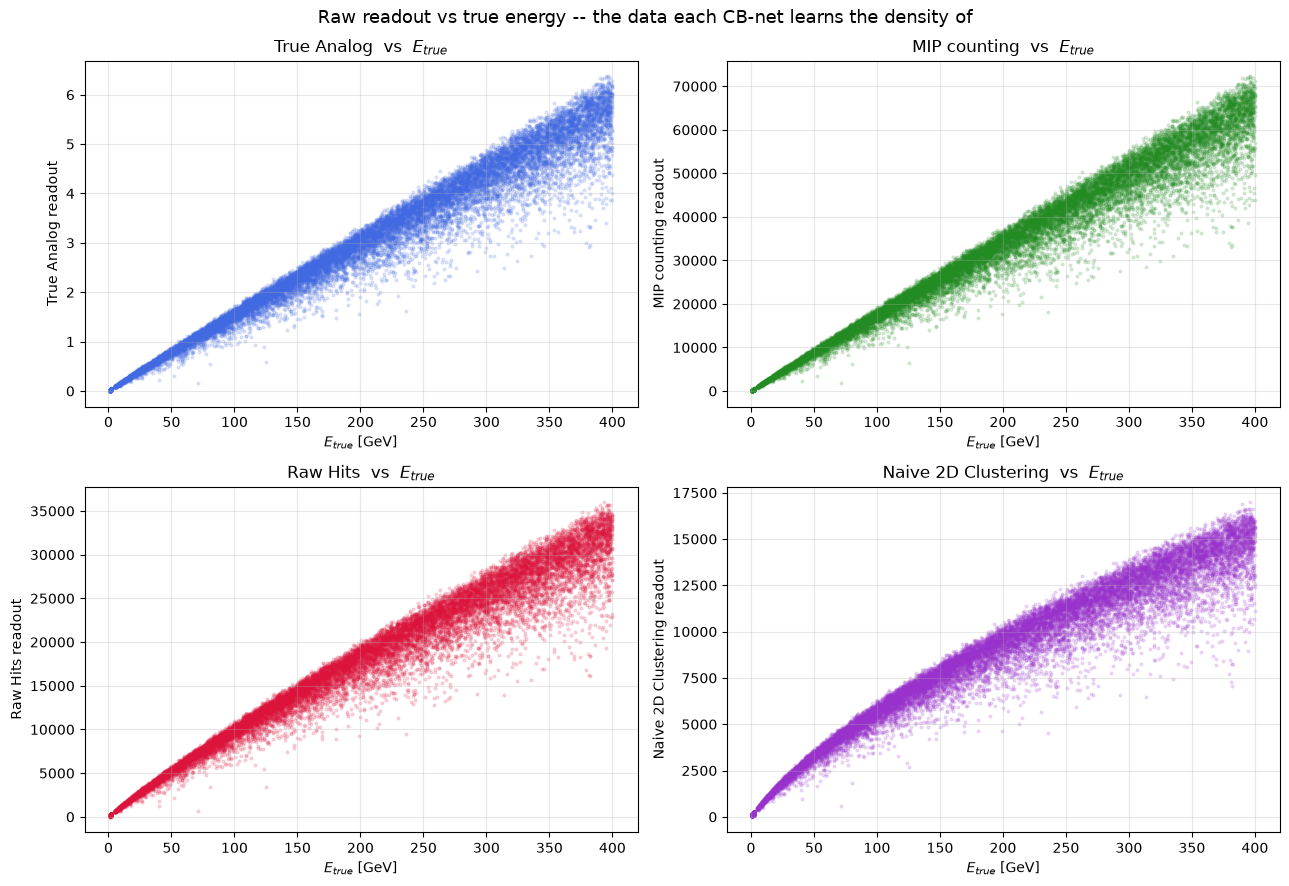

In [5]:
import matplotlib.pyplot as plt
readouts = {"True Analog": all_visible[valid], "MIP counting": all_mip[valid],
            "Raw Hits": all_hits[valid], "Naive 2D Clustering": all_cluster[valid]}
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (name, y) in zip(axes.flat, readouts.items()):
    ax.scatter(x_train, y, s=4, alpha=0.15, color=KEYCOL[name])
    ax.set_title(f"{name}  vs  $E_{{true}}$"); ax.set_xlabel("$E_{true}$ [GeV]")
    ax.set_ylabel(f"{name} readout"); ax.grid(True, alpha=0.3)
fig.suptitle("Raw readout vs true energy -- the data each CB-net learns the density of", fontsize=13)
plt.tight_layout(); plt.show()

## 5. Does the fit describe the data? — data vs conventional fit vs the network

The key sanity check, at a few **fixed energies** spanning the spectrum (using the dedicated
`mono_<particle>` runs, so the response is clean, not spectrum-smeared). Each panel shows the
actual response (histogram), the **conventional Crystal-Ball fit** (notebook 03's `fit_response` —
dashed black), and the **CB-net's predicted Crystal Ball** (solid colour). If the network is
doing its job, its curve tracks the data — and the conventional fit — reproducing the sharp
core **and** the low-side leakage tail that a single Gaussian cannot. This is the falsifiable
check on the density; everything downstream (the resolutions) is a summary of these shapes.
Everything is in fractional-response ($y/E_{\rm true}$) units so the energies are directly
comparable. (Analog shown; set `READOUT` for the digital readouts.)

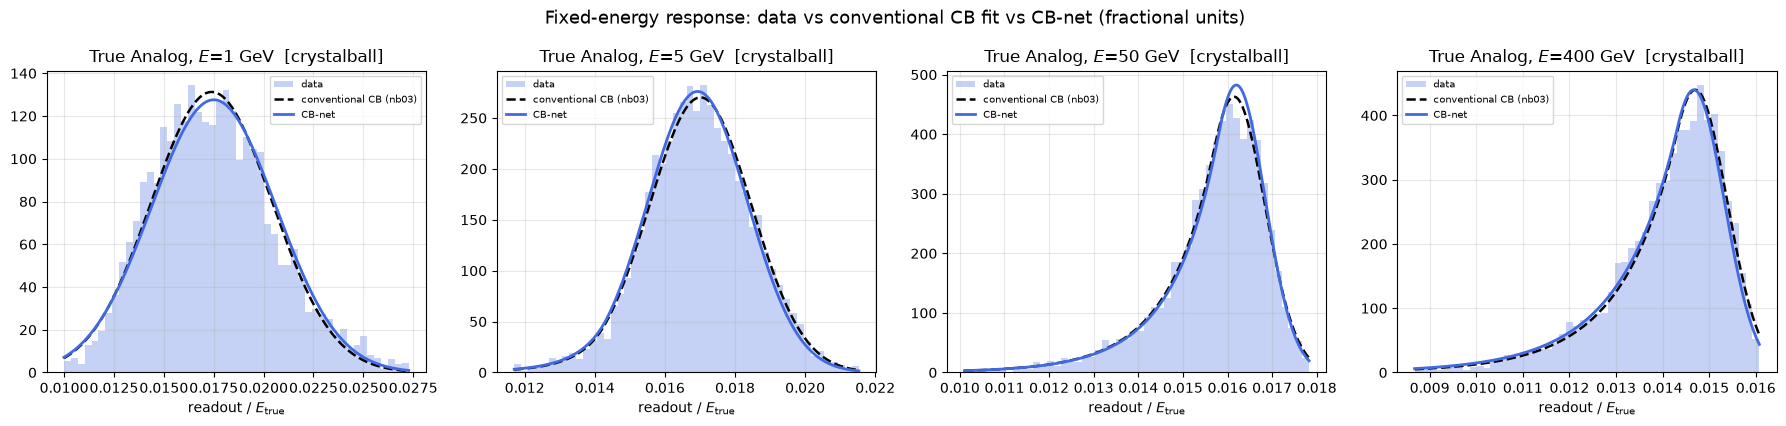

In [6]:
from scipy.stats import crystalball, norm

def predicted_cb(name, E):
    """CB-net predicted Crystal Ball (mu, sigma, alpha, n) at energy E, fractional units."""
    ens, xmax, ymax = ENS[name]
    p = cb_params_over_grid(ens, xmax, ymax, device, np.array([float(E)]))
    return p["mu"][0], p["sigma"][0], p["alpha"][0], p["n"][0]

MONO_DIR = os.path.join(CALOMAPS_HOME, "models", f"mono_{PART_TAG}")
READOUT = "True Analog"; RKEY = KEYNPZ[READOUT]
SHOW_E = [1, 5, 50, 400]                # fixed points across the full training range
fig, axes = plt.subplots(1, len(SHOW_E), figsize=(18, 4.3))
for ax, E in zip(axes, SHOW_E):
    f = os.path.join(MONO_DIR, f"decal_mono_{PART_TAG}_E{E:04d}GeV.npz")
    if not os.path.exists(f):
        ax.set_title(f"{E} GeV: no mono run"); ax.axis("off"); continue
    dd = np.load(f); Etrue = float(dd["E_nominal"]) if "E_nominal" in dd.files else float(E)
    r = dd[RKEY].astype(float) / Etrue          # fractional response
    lo, hi = np.percentile(r, [0.3, 99.7]); xx = np.linspace(lo, hi, 400)
    ax.hist(r, bins=50, range=(lo, hi), density=True, color=KEYCOL[READOUT], alpha=0.30, label="data")
    # conventional fit via the SHARED nb03 fitter (never raises; degrades CB->Gaussian->RMS)
    cf = fit_response(r)
    if cf["model"] == "crystalball":
        ax.plot(xx, crystalball.pdf(xx, cf["beta"], cf["m"], loc=cf["mu"], scale=cf["sigma"]),
                "--", color="k", lw=1.8, label="conventional CB (nb03)")
    elif cf["model"] == "gaussian":
        ax.plot(xx, norm.pdf(xx, loc=cf["mu"], scale=cf["sigma"]),
                "--", color="k", lw=1.8, label="conventional Gaussian (nb03)")
    nmu, nsg, nal, nnn = predicted_cb(READOUT, E)
    ax.plot(xx, crystalball.pdf(xx, nal, nnn, loc=nmu, scale=nsg), "-", color=KEYCOL[READOUT], lw=2, label="CB-net")
    ax.set_title(f"{READOUT}, $E$={E} GeV  [{cf['model']}]"); ax.set_xlabel(r"readout / $E_{\rm true}$")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
fig.suptitle("Fixed-energy response: data vs conventional CB fit vs CB-net (fractional units)", fontsize=13)
plt.tight_layout(); plt.show()

## 6. From the density to the resolution — **two** widths, via the calibration inversion

Because the network hands us the full Crystal Ball at each energy, the two widths come
straight from its parameters — and each is turned into an **energy** resolution by
inverting the learned calibration μ(E), the **same move notebook 03 makes** (a readout
width is not a resolution until you invert the response; essential for the saturating
digital readouts):

- **core** $\;\sigma_E/E$ — from the Gaussian-core width (identical definition to
  notebook 03's core),
- **effective** $\;\sigma_E/E$ — from the tail-inclusive $(P_{84}-P_{16})$ of the *same* CB.

Both quantities read the **same two Crystal-Ball numbers**, exactly as notebook 03 does:
the peak $\mu$ (the CB `loc` — the *most-probable* readout; note this is the **mode**, not
the mean — the low-side leakage tail drags the distribution's true mean **below** $\mu$)
and the **Gaussian-core** width $\sigma$ (the standard deviation of the core alone, **not**
the RMS of the whole distribution, which the tail inflates). The **core** resolution uses
$\sigma$ and so deliberately *excludes* the tail — precisely what notebook 03 quotes. The
tail is not discarded: the *same* fit's $(\alpha, n)$ put it back into the **effective**
width. So "core vs effective" is one fit read two ways, not two different fits.

The inversion is of a single smooth learned curve, evaluated over the **training domain**
— now the full 1–400 GeV (log-spaced grid).


In [7]:
E_LO, E_HI = float(x_train.min()), float(x_train.max())   # the actual training range (printed in §2)
E_GRID = np.logspace(np.log10(E_LO), np.log10(E_HI), 120)   # log-spaced over that range
res = {}
for name, (ens, xmax, ymax) in ENS.items():
    cb, core, eff = resolution_over_grid(ens, xmax, ymax, device, E_GRID)
    res[name] = {"cb": cb, "core": core, "eff": eff}
print(f"extracted core and effective sigma_E/E for 4 readouts over "
      f"{E_GRID.min():.0f}-{E_GRID.max():.0f} GeV (energy-domain, inverted)")

extracted core and effective sigma_E/E for 4 readouts over 1-400 GeV (energy-domain, inverted)


## 7. Head-to-head: ML density net vs the conventional fixed-energy fit

The direct comparison, both sides in **energy** units (σ_E/E), both inverted through a
calibration. **Lines** = the CB-density net, trained on the spectrum + anchors. **Points**
= the conventional method (notebook 03): a Crystal-Ball fit to each fixed-energy run, its
per-readout calibration built and inverted exactly as in notebook 03 (circles = the
inverted Gaussian-**core** σ_E/E; squares = the inverted data central-68%,
$(P_{84}-P_{16})$); without those runs the panel shows the CB-net lines alone. If the ML
density net is right, the lines track the points across the **full 1–400 GeV** — core-on-core
(left) and effective-on-effective (right), to within the small residual offset §8 quantifies. Read the **high-energy endpoint**
with some caution — it is a one-sided, unconstrained boundary of the training domain, so the
tail parameters there are extrapolation-sensitive (see §10); the 1–2 GeV end is pinned by the
dedicated anchor runs (whose conventional points there are fits to the *same* events the net
trained on, so they check the fit, not generalization — the ≥5 GeV points are the independent
test; §8b retrains on a disjoint mono-only set as a further check).


conventional fits by model: {'crystalball': 36, 'gaussian': 0, 'rms': 0, 'none': 0}   (gaussian/rms = graceful-degrade fallbacks, shown so a fallback can't silently masquerade as a CB result)


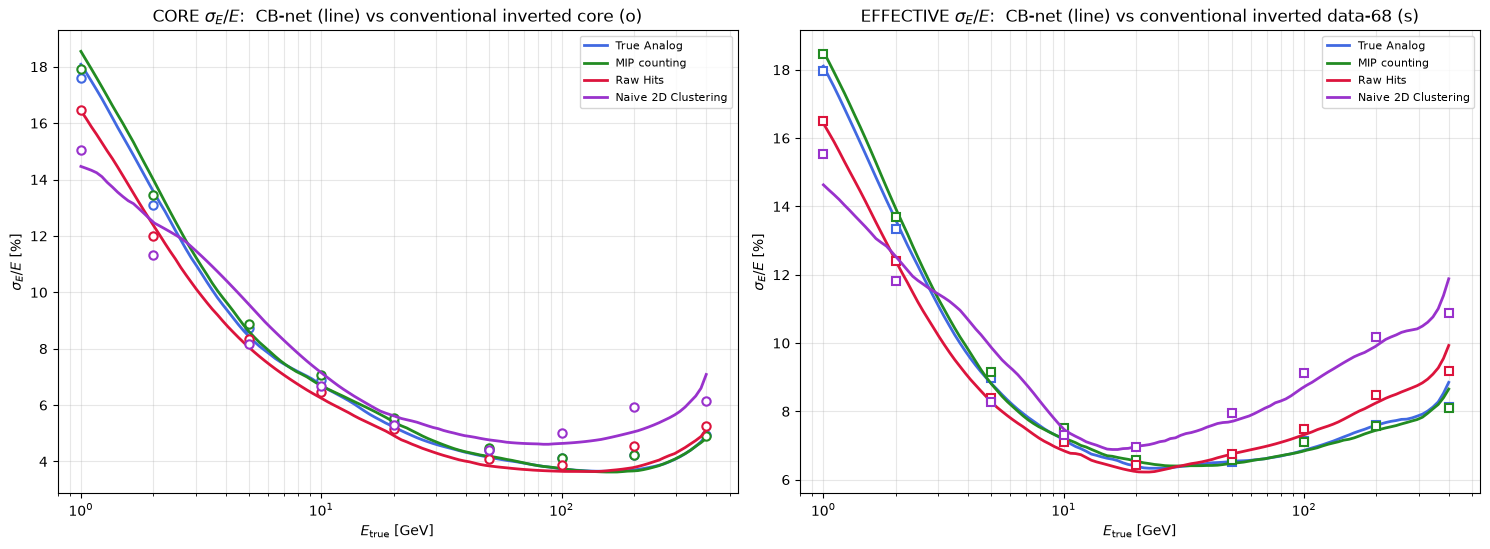

In [8]:
import glob
mono_files = sorted(glob.glob(os.path.join(MONO_DIR, "*.npz")))
# pass 1: fit every (readout, energy) with the SHARED nb03 fitter; record mu, sigma, data P16/P84
raw = {name: {"E": [], "mu": [], "sig": [], "p16": [], "p84": []} for name in ENS}
_models = {"crystalball": 0, "gaussian": 0, "rms": 0, "none": 0}
for f in mono_files:
    d = np.load(f); E = float(d["E_nominal"]) if "E_nominal" in d.files else float(np.median(d["all_truth"]))
    for name in ENS:
        v = np.asarray(d[KEYNPZ[name]], float); v = v[np.isfinite(v)]
        r = fit_response(v); _models[r["model"]] = _models.get(r["model"], 0) + 1
        if not (r["ok"] and r["mu"] > 0):
            continue
        p16, p84 = np.percentile(v, [15.87, 84.13])
        raw[name]["E"].append(E); raw[name]["mu"].append(r["mu"]); raw[name]["sig"].append(r["sigma"])
        raw[name]["p16"].append(p16); raw[name]["p84"].append(p84)
print(f"conventional fits by model: {_models}   (gaussian/rms = graceful-degrade fallbacks, shown so a "
      f"fallback can't silently masquerade as a CB result)")

# pass 2: per readout, build the calibration from its own mu(E) and INVERT both bands to sigma_E/E
conv = {}
for name in ENS:
    E = np.array(raw[name]["E"]); mu = np.array(raw[name]["mu"]); sig = np.array(raw[name]["sig"])
    p16 = np.array(raw[name]["p16"]); p84 = np.array(raw[name]["p84"])
    if np.unique(E).size < 2:
        conv[name] = None; continue
    _, ginv, _, _ = build_calibration(E, mu)
    core = (ginv(mu + sig) - ginv(np.maximum(mu - sig, 1e-9))) / (2.0 * E)          # inverted core (== nb03)
    eff  = (ginv(np.maximum(p84, 1e-9)) - ginv(np.maximum(p16, 1e-9))) / (2.0 * E)  # inverted data 68% (tail-inclusive)
    conv[name] = {"E": E, "core": core * 100, "eff": eff * 100}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
for name in ENS:
    c = KEYCOL[name]
    axes[0].plot(E_GRID, res[name]["core"]*100, "-", color=c, lw=2, label=name)
    axes[1].plot(E_GRID, res[name]["eff"]*100,  "-", color=c, lw=2, label=name)
    if conv.get(name) is not None:
        axes[0].plot(conv[name]["E"], conv[name]["core"], "o", color=c, ms=6, mfc="white", mew=1.5)
        axes[1].plot(conv[name]["E"], conv[name]["eff"],  "s", color=c, ms=6, mfc="white", mew=1.5)
axes[0].set_title(r"CORE $\sigma_E/E$:  CB-net (line) vs conventional inverted core (o)")
axes[1].set_title(r"EFFECTIVE $\sigma_E/E$:  CB-net (line) vs conventional inverted data-68 (s)")
E_LO = float(E_GRID.min())                              # training-range low edge (from §6)
_lefts = [E_LO] + [float(np.min(c["E"])) for c in conv.values() if c is not None]
_left = max(0.5, min(_lefts) * 0.8)                     # show any sub-range mono points too
for ax in axes:
    ax.set_xscale("log"); ax.set_xlim(left=_left)
    if min(_lefts) < E_LO:                              # only shade if points sit below the training domain
        ax.axvspan(_left, E_LO, color="gray", alpha=0.08)
        ax.axvline(E_LO, color="gray", ls=":", lw=1)
    ax.set_xlabel(r"$E_{\rm true}$ [GeV]")
    ax.set_ylabel(r"$\sigma_E/E$ [%]"); ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
if not mono_files:
    fig.suptitle("(no models/mono_<tag> runs found -> conventional points skipped; showing CB-net only)", fontsize=10)
plt.tight_layout(); plt.show()

## 8. The $\sigma_E/E$ vs $1/\sqrt{E}$ money plot — directly comparable to notebook 03 §8

The same data as §7, re-plotted the way notebook 03 §8 does: the **core** $\sigma_E/E$
against $1/\sqrt{E}$, where a purely stochastic resolution is a **straight line through
the origin**. We fit the calorimeter law $\sigma_E/E = a/\sqrt{E}\oplus b$ (no $c/E$ —
this simulation has no electronics noise) to the CB-net core and print $a$ (stochastic,
%·$\sqrt{\rm GeV}$) and $b$ (constant, %) so you can compare **number-for-number** with
notebook 03's fit. Open circles are the conventional fixed-energy core (notebook 03's
method) on the same axes.


readout                  CB-net core:  a/sqrt(E) (+) b
True Analog             a =  18.1 / sqrt(E)  (+)  b = 3.47 %
MIP counting            a =  18.6 / sqrt(E)  (+)  b = 3.45 %
Raw Hits                a =  16.5 / sqrt(E)  (+)  b = 3.50 %
Naive 2D Clustering     a =  15.9 / sqrt(E)  (+)  b = 4.88 %


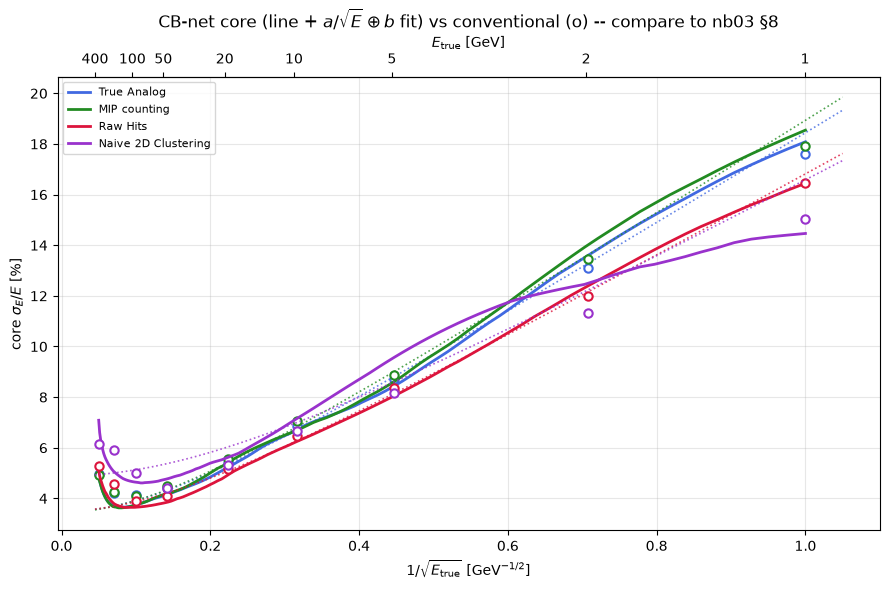

In [9]:
from scipy.optimize import curve_fit
def _fit_ab(E, frac):
    """Fit sigma_E/E = a/sqrt(E) (+) b (quadrature) to a fractional-resolution curve."""
    m = lambda E, a, b: np.sqrt((a / np.sqrt(E))**2 + b**2)
    ok = np.isfinite(E) & np.isfinite(frac) & (frac > 0)
    try:
        p, _ = curve_fit(m, np.asarray(E)[ok], np.asarray(frac)[ok], p0=[0.2, 0.04],
                         bounds=([0, 0], [np.inf, np.inf]), maxfev=40000)
        return p, m
    except Exception:
        return None, m

fig, ax = plt.subplots(figsize=(9, 6))
print(f"{'readout':<20}{'CB-net core:  a/sqrt(E) (+) b':>34}")
for name in ENS:
    c = KEYCOL[name]; x = 1.0 / np.sqrt(E_GRID)
    ax.plot(x, res[name]["core"] * 100, "-", color=c, lw=2, label=name)
    p, m = _fit_ab(E_GRID, res[name]["core"])
    if p is not None:
        xx = np.linspace(x.min() * 0.9, x.max() * 1.05, 200)
        ax.plot(xx, 100 * m(1.0 / xx**2, *p), ":", color=c, lw=1.2, alpha=0.8)
        print(f"{name:<20}    a = {100*p[0]:5.1f} / sqrt(E)  (+)  b = {100*p[1]:4.2f} %")
    if conv.get(name) is not None:                       # nb03 conventional core, same axes
        ax.plot(1.0 / np.sqrt(conv[name]["E"]), conv[name]["core"], "o", color=c, ms=6, mfc="white", mew=1.5)
ax.set_xlabel(r"$1/\sqrt{E_{\rm true}}$ [GeV$^{-1/2}$]"); ax.set_ylabel(r"core $\sigma_E/E$ [%]")
ax.set_title(r"CB-net core (line + $a/\sqrt{E}\oplus b$ fit) vs conventional (o) -- compare to nb03 §8")
def _toe(x):   return 1.0 / np.clip(np.asarray(x, float), 1e-6, None)**2
def _frome(E): return 1.0 / np.sqrt(np.clip(np.asarray(E, float), 1e-6, None))
sec = ax.secondary_xaxis("top", functions=(_toe, _frome))
sec.set_xlabel(r"$E_{\rm true}$ [GeV]"); sec.set_xticks([400, 100, 50, 20, 10, 5, 2, 1])
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

**How well does this match notebook 03?** The **stochastic term $a$ agrees** (at low
energy, where $a$ dominates, the line runs close to the conventional circles — including the
1–2 GeV anchor points). The **constant term $b$ runs ~0.5% *lower*** here than in notebook
03: the network fits the core by unbinned maximum likelihood, which pins the peak slightly
tighter than notebook 03's binned-$\chi^2$ fit, so at the *same* tail split $\alpha$ its
Gaussian core is ~10–20% narrower (more so at high energy, where the tail is larger). Both
are legitimate estimates of "the core width" — the difference is the fit method, not the
physics. **Clustering** shows the largest gap at the *low* end: at 1–2 GeV its readout is
a small-integer count (a handful of clusters), and a *continuous* Crystal Ball is the wrong
density for a near-integer distribution — notebook 03's *binned* $\chi^2$ fit still resolves a
core there where this net's *unbinned continuous* NLL strains more (both handle the discreteness
imperfectly, differently; and for this photon data neither triggers the RMS fallback). The **effective** $\sigma_E/E$ (§7 right panel,
tail-inclusive) sits *above* these core values, as it must.


## 8b. Robustness cross-check: does the training-set composition matter?

§2 argued that mixing a continuous spectrum with two mono-energetic anchors is harmless
because the network learns a **conditional** density p(readout | E) — the marginal
distribution of E in the training set only weights the fit. That argument should not be
taken on faith; it can be tested. Here we retrain the whole model on a completely
different E-marginal: the **nine mono-energetic runs alone** (1–400 GeV, 5000 events each
— notebook 03's inputs, no spectrum at all) — and evaluate the same resolutions over the
same grid.

The two training sets have opposite pathologies: the spectrum has continuous coverage but
almost no weight below 5 GeV; the mono set has strong anchors at nine energies and
*nothing in between*. If the learned resolution curves agree anyway — and both pass
through the conventional points — the E-marginal really is irrelevant and the smooth
parameterization is doing its job. Where they disagree, the disagreement localizes what
neither marginal can constrain (in practice: the sparse spectrum boundary at the top of
the range, and interpolation between widely spaced mono points). The printed table
quantifies the relative difference per readout. Set `CB_XCHECK_RETRAIN=0` to reuse
previously trained mono-only ensembles.


In [10]:
# train (or load) a second set of ensembles on the MONO-ONLY training set
import glob as _glob
mono_files_all = sorted(_glob.glob(os.path.join(CALOMAPS_HOME, "models", f"mono_{PART_TAG}", "*.npz")))
m_parts = [{k: np.asarray(np.load(f)[k], float) for k in _KEYS} for f in mono_files_all]
mt = np.concatenate([p["all_truth"] for p in m_parts])
mv = {kk: np.concatenate([p[kk] for p in m_parts]) for kk in _KEYS[1:]}
mvalid = mt > 0
for kk in _KEYS[1:]:
    mvalid &= mv[kk] > 0
print(f"mono-only training set: {int(mvalid.sum())} events at {np.unique(mt[mvalid]).size} energies "
      f"[{mt[mvalid].min():.0f}, {mt[mvalid].max():.0f}] GeV   (spectrum: NOT used here)")

XDIR = os.path.join(CALOMAPS_HOME, "models", f"saved_cbnet_gpu_{PART_TAG}_monoonly")
os.makedirs(XDIR, exist_ok=True)
_xspecs = [("True Analog", "all_visible", 1000, "cb_analog.pth"),
           ("MIP counting", "all_mip", 2000, "cb_mip.pth"),
           ("Raw Hits", "all_hits", 3000, "cb_hits.pth"),
           ("Naive 2D Clustering", "all_cluster", 4000, "cb_cluster.pth")]
_have_x = all(os.path.exists(os.path.join(XDIR, fn)) for *_, fn in _xspecs)
if os.environ.get("CB_XCHECK_RETRAIN", "1") == "1" or not _have_x:
    for label, key, seed, fname in _xspecs:
        ens, xmax, ymax = train_one_ensemble(mt[mvalid], mv[key][mvalid], device,
                                             name=f"{label} (mono-only)", num_models=_NM,
                                             epochs=_EP, seed_base=seed + 500)
        save_ensemble(ens, xmax, ymax, os.path.join(XDIR, fname))
else:
    print(f"Loading existing mono-only ensembles from {XDIR}")
resx = {}
for label, key, seed, fname in _xspecs:
    e_, xm_, ym_ = load_ensemble(os.path.join(XDIR, fname), device)
    _, core, eff = resolution_over_grid(e_, xm_, ym_, device, E_GRID)
    resx[label] = {"core": core, "eff": eff}
print("mono-only-trained core/effective extracted over the same 1-400 GeV grid")


mono-only training set: 45000 events at 9 energies [1, 400] GeV   (spectrum: NOT used here)
Loading existing mono-only ensembles from /nashome/m/murtazas/CALOMAPS-rework/models/saved_cbnet_gpu_gamma_monoonly


mono-only-trained core/effective extracted over the same 1-400 GeV grid


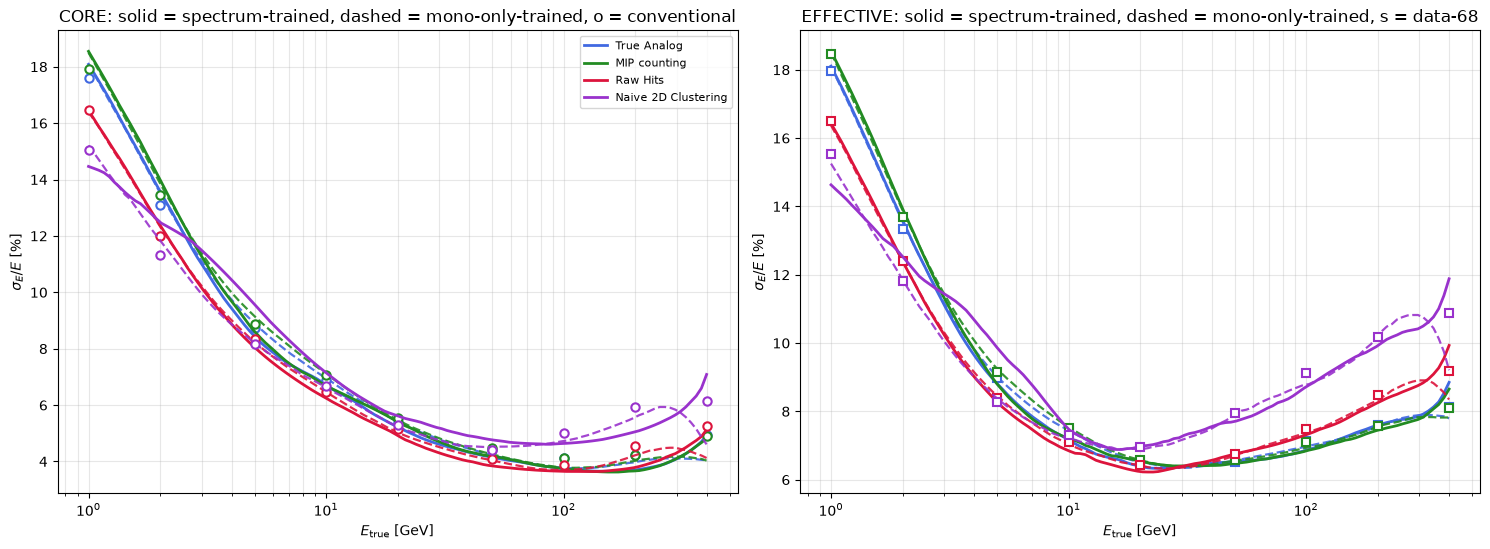

readout                  median |Δcore|/core    max |Δcore|/core
True Analog                            3.1%              17.9%
MIP counting                           2.4%              16.4%
Raw Hits                               2.7%              19.5%
Naive 2D Clustering                    7.2%              35.0%
solid-vs-dashed agreement (with both passing through the conventional points) is the
direct demonstration that the training set's E-marginal does not shape the learned density.


In [11]:
# overlay: spectrum(+anchors)-trained vs mono-only-trained vs conventional
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
for name in ENS:
    c = KEYCOL[name]
    axes[0].plot(E_GRID, res[name]["core"] * 100, "-", color=c, lw=2, label=name)
    axes[0].plot(E_GRID, resx[name]["core"] * 100, "--", color=c, lw=1.6, alpha=0.9)
    axes[1].plot(E_GRID, res[name]["eff"] * 100, "-", color=c, lw=2)
    axes[1].plot(E_GRID, resx[name]["eff"] * 100, "--", color=c, lw=1.6, alpha=0.9)
    if conv.get(name) is not None:
        axes[0].plot(conv[name]["E"], conv[name]["core"], "o", color=c, ms=6, mfc="white", mew=1.5)
        axes[1].plot(conv[name]["E"], conv[name]["eff"], "s", color=c, ms=6, mfc="white", mew=1.5)
axes[0].set_title("CORE: solid = spectrum-trained, dashed = mono-only-trained, o = conventional")
axes[1].set_title("EFFECTIVE: solid = spectrum-trained, dashed = mono-only-trained, s = data-68")
for ax in axes:
    ax.set_xscale("log"); ax.set_xlabel(r"$E_{\rm true}$ [GeV]"); ax.set_ylabel(r"$\sigma_E/E$ [%]")
    ax.grid(alpha=0.3, which="both")
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"{'readout':<22}{'median |Δcore|/core':>22}{'max |Δcore|/core':>20}")
for name in ENS:
    a_, b_ = res[name]["core"], resx[name]["core"]
    rel = np.abs(a_ - b_) / np.where(a_ > 0, a_, np.nan)
    print(f"{name:<22}{100 * np.nanmedian(rel):>20.1f}%{100 * np.nanmax(rel):>18.1f}%")
print("solid-vs-dashed agreement (with both passing through the conventional points) is the")
print("direct demonstration that the training set's E-marginal does not shape the learned density.")


## 9. The learned response / calibration

The network's learned **response** μ(E) — the Crystal-Ball **peak** (most-probable
readout, the CB `loc`, *not* the mean: the low-side leakage tail pulls the true mean below
the peak). This is the very curve §6–§7 inverted, and it is the ML analogue of the
**measured** calibration in notebook 03 §6 — compare the two directly. Straight on log-log
= linear; the digital readouts bend over as they saturate — the root cause of the
core/effective divergence. The sharpest data-level check of the model remains §5 (the
predicted density tracking the fixed-energy histograms); this curve is the summary object.


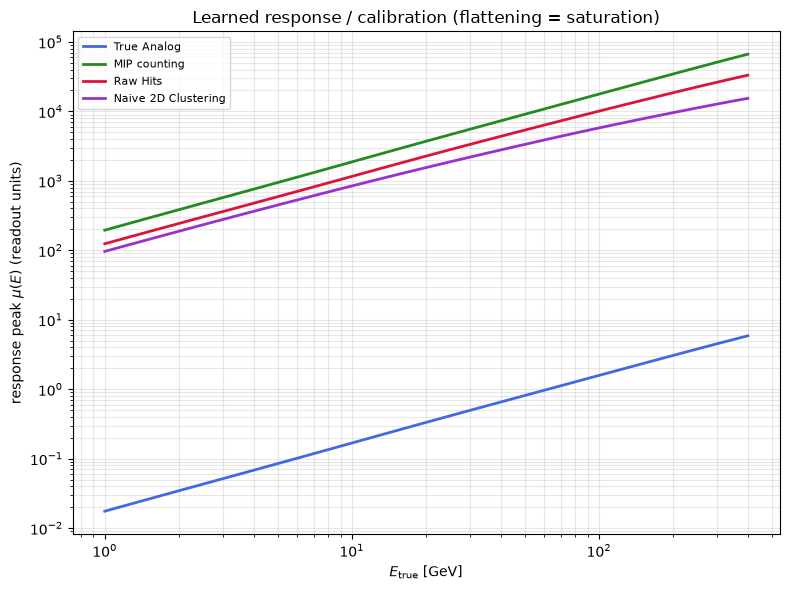

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
for name in ENS:
    ax.plot(E_GRID, res[name]["cb"]["mu"] * E_GRID, "-", color=KEYCOL[name], lw=2, label=name)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$E_{\rm true}$ [GeV]"); ax.set_ylabel(r"response peak $\mu(E)$ (readout units)")
ax.set_title("Learned response / calibration (flattening = saturation)")
ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

## 10. What this reconciles — and its limits

**One model, both numbers.** From a single training the CB-density net reproduces the
conventional fixed-energy result (inverted **core** σ_E/E, the circles) *and* the
tail-inclusive data width (inverted **effective** σ_E/E, the squares) — across the full
1–400 GeV. The gap between the core and effective curves **is** the growing low-side
leakage tail; both are real, and quoting only the core is optimistic wherever the tail is
large.

**Versus notebook 03:** the ML net delivers the whole curve from one training, with no
dedicated fixed-energy runs required beyond the two low-energy anchors; notebook 03 remains
the transparent ground truth, and the overlays here confirm the net against it
point-by-point.

**Limits to keep honest:**
- **Between the anchors (2–5 GeV) the net interpolates.** The only constraint there is the
  smoothness of the parameterization; the 5 GeV conventional point sits at the spectrum
  edge and checks the interpolation from above, and §8b's mono-only retraining — with
  support at 2 and 5 GeV but nothing between — probes the complementary failure mode;
  the two nets' agreement bounds the interpolation error. Adding more mono runs to the training set
  is the obvious extension if that region ever becomes the point.
- **High-energy edge.** The top of the range is a one-sided, unconstrained boundary of the
  training domain (this spectrum is uniform in $|p|$, so it is not actually the sparsest region —
  that is the low edge — but it is the least constrained *edge*), so the CB parameters — the tail
  especially —
  are least determined exactly where core and effective diverge most. Read the endpoint
  values as boundary extrapolations, not precision numbers.
- **Core vs notebook 03 is a ~0.5% agreement, not exact (§8).** The net's unbinned-ML core
  runs slightly narrower than the binned-$\chi^2$ core at the same tail split, so the
  stochastic term $a$ matches but the constant term $b$ is ~0.5% lower; clustering diverges
  more at 1–2 GeV where its readout is a discrete count. Fit-method differences, not
  physics disagreements.
- **A Crystal Ball is still an assumed shape.** It fits this core+low-tail response well
  (§5); a response with a *high*-side tail (hadrons — see notebook 03's pion caveat) would
  need a different density, and the single-peak CB would misreport the width.
